In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import json
from scipy import integrate

## ONNX

In [16]:
model_variants = ["yolov5nu", "yolov5su", "yolov5mu", "yolov5lu"]
quant_model_variants = ["yolov5nu.quant", "yolov5su.quant", "yolov5mu.quant", "yolov5lu.quant"]
results_dir = Path("../raw_data/onnx_quantize_models_cpu")

In [17]:
def read_model(model_name):
    power_df = pd.read_csv(results_dir / model_name / f"{model_name}_power_log.log", names=["time", "voltage", "current"], parse_dates=[0])
    with open(results_dir / model_name / f"{model_name}_pytorch.json") as f:
        timings = json.load(f)
    with open(results_dir / model_name / "validation_results.json") as f:
        results = json.load(f)
    return power_df, timings, results


In [18]:
idle_power = 3889678.687218899

In [19]:
def calculate_metrics(model_name: str, plot=False):
    """Calculates metrics and returns a dict with all metrics for a given model measurements.

    'Active' part is defined as part of the time series between the first and the last instance 
    of power readings above a certain arbitrary threshold, e.g. 1 W.
    

    Returns: 
        a dict of:
        "mean_active_power": mean power of the 'active' part of the measurements in W
        "max_active_power": max power of the 'active' part of the measurements in W
        "wall_time": time we recorded before and after validation method was called in sec
        "active_time": time taken by the 'active' part of the measurements in sec
        "inference_time": inference time as reported by ultralytics in sec
        "mean_active_energy": energy according to mean power and active time in J
        "max_active_energy": energy according to max power and active time in J
        "mean_inference_energy": energy according to mean power and inference time in J
        "max_inference_energy": energy according to max power and inference time in J
        "integrated_energy": energy by integration (trapezoid method) in J
    """
    power_df, timings, ultralytics_results = read_model(model_name)
    
    start_time = pd.to_datetime(timings["start_time"], unit='s')
    end_time = pd.to_datetime(timings["end_time"], unit='s')
    wall_time = (end_time - start_time).total_seconds()
    inference_time = ultralytics_results["speed"]["inference"]
    power_profile = power_df[(power_df.time >= start_time) & (power_df.time <= end_time)]
    # Get power profile subtracting the idle power
    power_profile.loc[:, ["power"]] = (power_profile.current * power_profile.voltage - idle_power) / 10**6

    # Get framework overhead power (the low parts before and after active part)
    framework_power_overhead = power_profile.power.iloc[:1000].mean()
    power_profile.loc[:, "power"] = (power_profile.power - framework_power_overhead)
    filtered_time = power_profile[power_profile.power > 1].time
    active_power_profile = power_profile.loc[(power_df.time >= filtered_time.min()) & (power_df.time <= filtered_time.max())]
    
    if plot:
        sns.lineplot(power_profile, x="time", y="power")
        sns.lineplot(active_power_profile, x="time", y="power")
        plt.show()
    
    mean_active_power = active_power_profile.power.mean()
    max_active_power = active_power_profile.power.max()
    active_time = (active_power_profile.time.iloc[-1] - active_power_profile.time.iloc[0]).total_seconds()
    integrated_energy = integrate.trapezoid(active_power_profile.power, x=active_power_profile.time.apply(lambda x: x.timestamp()))
    result = {
        "mean_active_power": mean_active_power,
        "max_active_power": max_active_power,
        "wall_time": wall_time,
        "active_time": active_time,
        "inference_time": inference_time,
        "mean_active_energy": mean_active_power * active_time,
        "max_active_energy": max_active_power * active_time,
        "mean_inference_energy": mean_active_power * inference_time,
        "max_inference_energy": max_active_power * inference_time,
        "integrated_energy": integrated_energy,
    }
    result.update(ultralytics_results["metrics"])
    return result


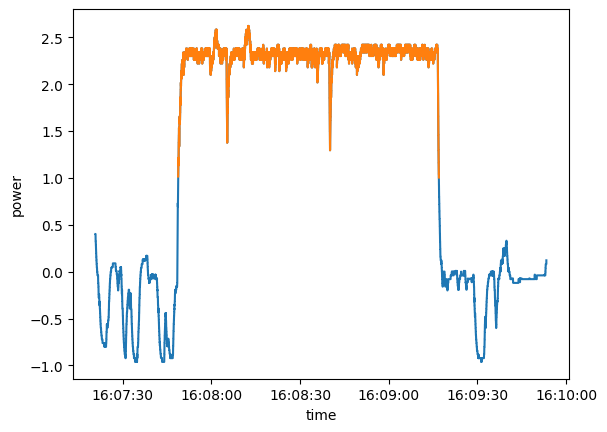

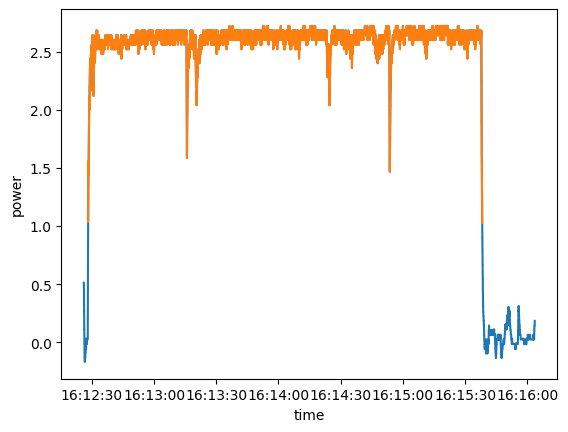

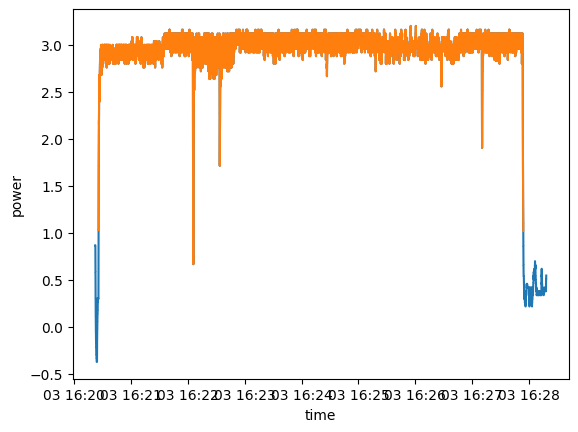

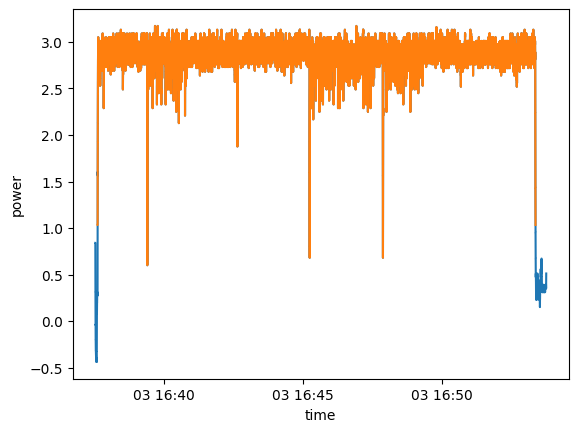

In [20]:
measurements_df = pd.DataFrame({model_name: calculate_metrics(model_name, plot=True) for model_name in model_variants}).T

In [21]:
measurements_df

,mean_active_power,max_active_power,wall_time,active_time,inference_time,mean_active_energy,max_active_energy,mean_inference_energy,max_inference_energy,integrated_energy,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),fitness
yolov5nu,2.310828,2.621267,152.550379,88.197690,150.576807,203.809669,231.189723,347.957065,394.702066,203.722553,0.598330,0.458862,0.512687,0.363922,0.378798
yolov5su,2.616663,2.724219,217.403242,190.008007,354.376892,497.186933,517.623400,927.284923,965.400220,497.072868,0.725598,0.542873,0.614107,0.458419,0.473987
yolov5mu,2.994727,3.200079,475.997832,448.353514,868.198447,1342.696471,1434.766482,2600.017518,2778.303265,1342.557643,0.685307,0.623068,0.671167,0.517078,0.532487
yolov5lu,2.897445,3.172316,972.195905,944.146660,1852.045906,2735.612912,2995.132009,5366.200939,5875.275748,2735.047863,0.716409,0.649791,0.706582,0.555251,0.570384


Model Quantization Measurements

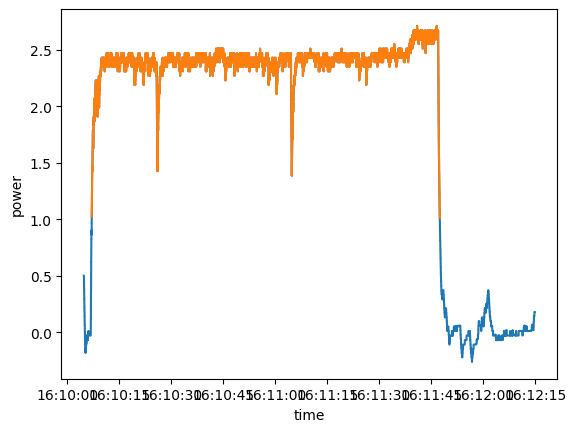

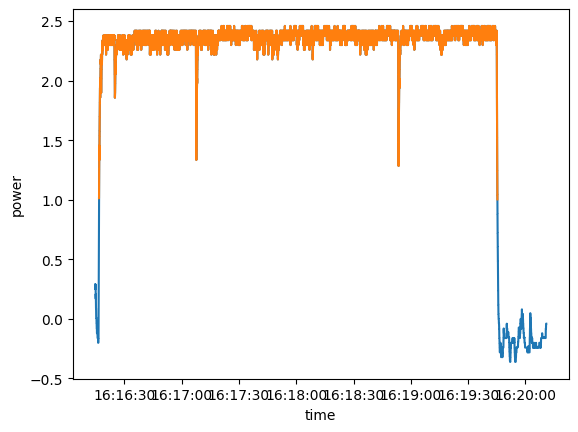

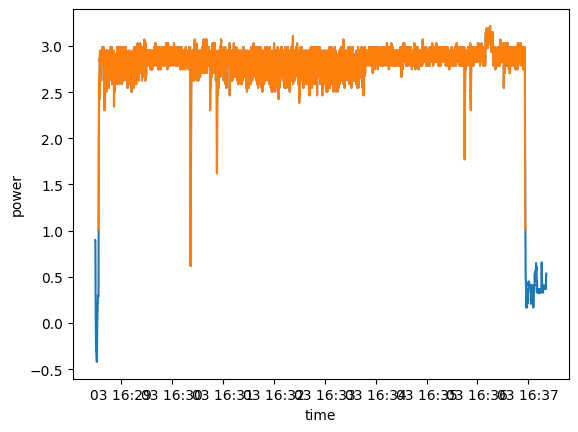

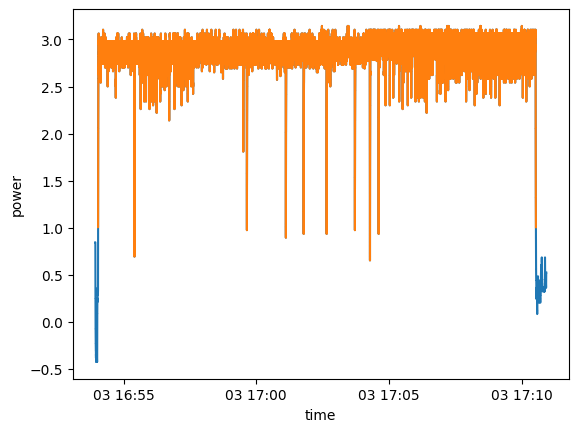

In [22]:
quant_measurements_df = pd.DataFrame({model_name: calculate_metrics(model_name, plot=True) for model_name in quant_model_variants}).T

In [23]:
quant_measurements_df

,mean_active_power,max_active_power,wall_time,active_time,inference_time,mean_active_energy,max_active_energy,mean_inference_energy,max_inference_energy,integrated_energy,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),fitness
yolov5nu.quant,2.404238,2.711018,130.097333,100.414428,174.576520,241.420202,272.225282,419.723535,473.280018,241.332829,0.584919,0.445373,0.500369,0.348049,0.363281
yolov5su.quant,2.368606,2.459665,236.012376,208.532435,391.566023,493.931135,512.919883,927.465553,963.121151,493.842072,0.686345,0.536246,0.593575,0.435495,0.451303
yolov5mu.quant,2.883927,3.217377,531.618631,503.160453,969.958419,1451.077980,1618.856752,2797.289205,3120.721684,1450.756813,0.696109,0.586812,0.659530,0.502056,0.517803
yolov5lu.quant,2.897713,3.144076,1019.779680,990.222002,1937.758001,2869.379546,3113.333516,5615.067289,6092.458982,2868.843277,0.722061,0.641225,0.694830,0.538118,0.553789


In [24]:
def scatter_text(x, y, text_column, data, title, xlabel, ylabel):
    """Scatter plot with country codes on the x y coordinates
       Based on this answer: https://stackoverflow.com/a/54789170/2641825"""
    # Create the scatter plot
    p1 = sns.scatterplot(x=x, y=y, data=data, size = 8, legend=False)
    # Add text besides each point
    for line in range(0,data.shape[0]):
         p1.text(data[x][line]+0.01, data[y][line], 
                 data[text_column][line], horizontalalignment='left', 
                 size='medium', color='black', weight='semibold')
    # Set title and axis labels
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    return p1

<Axes: title={'center': 'YOLOv5 Baseline'}, xlabel='Valdation Energy Consumption (J)', ylabel='mAP50-95'>

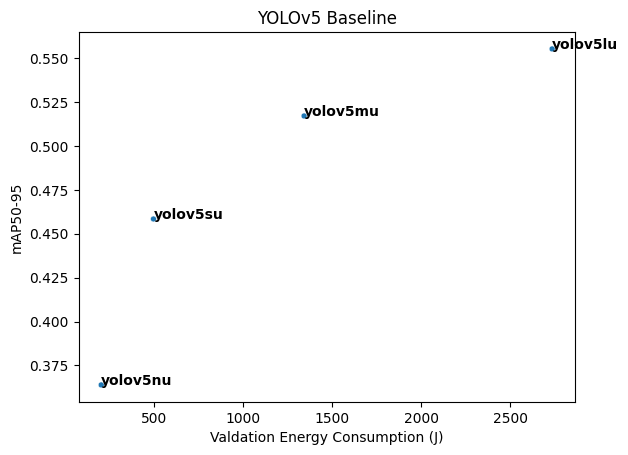

In [25]:
scatter_text("integrated_energy", "metrics/mAP50-95(B)", "index", data=measurements_df.reset_index(), title="YOLOv5 Baseline", xlabel="Valdation Energy Consumption (J)", ylabel="mAP50-95")

<Axes: title={'center': 'YOLOv5 Model Quantization (INT8 ONNX)'}, xlabel='Valdation Energy Consumption (J)', ylabel='mAP50-95'>

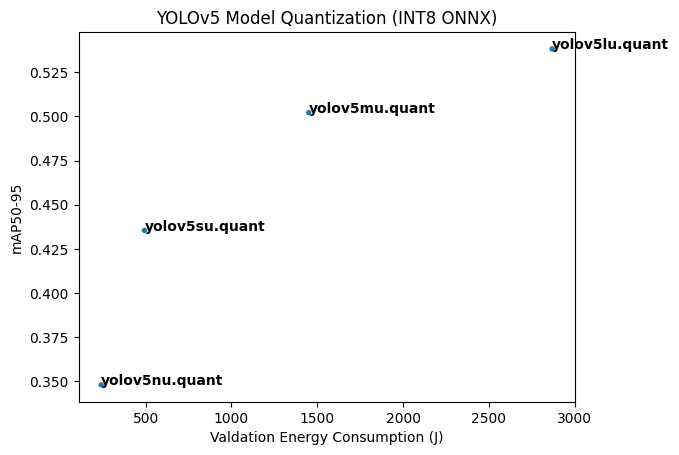

In [26]:
scatter_text("integrated_energy", "metrics/mAP50-95(B)", "index", data=quant_measurements_df.reset_index(), title="YOLOv5 Model Quantization (INT8 ONNX)", xlabel="Valdation Energy Consumption (J)", ylabel="mAP50-95")

<Axes: title={'center': 'YOLOv5 Baseline and Model Quantization'}, xlabel='Valdation Energy Consumption (J)', ylabel='mAP50-95'>

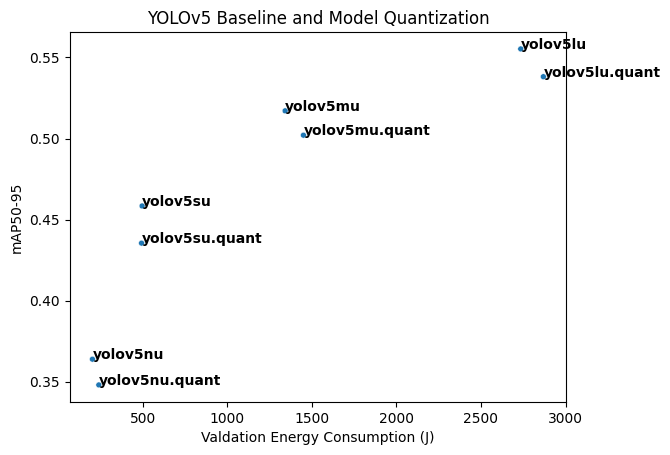

In [27]:
df = pd.concat([measurements_df.reset_index(), quant_measurements_df.reset_index()], ignore_index=True)
scatter_text("integrated_energy", "metrics/mAP50-95(B)", "index", data=df.reset_index(), title="YOLOv5 Baseline and Model Quantization", xlabel="Valdation Energy Consumption (J)", ylabel="mAP50-95")

In [28]:
df.to_csv("../processed_data/model_quantization_measurements.csv")

## TensorRT

In [2]:
model_variants = ["yolov5nu_trt.engine", "yolov5su_trt.engine", "yolov5mu_trt.engine", "yolov5lu_trt.engine"]
quant_model_variants = ["yolov5nu_quant_trt.engine", "yolov5su_quant_trt.engine", "yolov5mu_quant_trt.engine", "yolov5lu_quant_trt.engine"]
results_dir = Path("../raw_data/trt_quantize_models")

In [3]:
def read_model(model_name):
    power_df = pd.read_csv(results_dir / model_name / f"{model_name}_power_log.log", names=["time", "voltage", "current"], parse_dates=[0])
    with open(results_dir / model_name / f"{model_name}.json") as f:
        timings = json.load(f)
    with open(results_dir / model_name / "validation_results.json") as f:
        results = json.load(f)
    return power_df, timings, results


In [4]:
idle_power = 4121119.056401573

In [11]:
def calculate_metrics(model_name: str, index: int = 5000, plot=False):
    """Calculates metrics and returns a dict with all metrics for a given model measurements.

    'Active' part is defined as part of the time series between the first and the last instance 
    of power readings above a certain arbitrary threshold, e.g. 1 W.
    

    Returns: 
        a dict of:
        "mean_active_power": mean power of the 'active' part of the measurements in W
        "max_active_power": max power of the 'active' part of the measurements in W
        "wall_time": time we recorded before and after validation method was called in sec
        "active_time": time taken by the 'active' part of the measurements in sec
        "inference_time": inference time as reported by ultralytics in sec
        "mean_active_energy": energy according to mean power and active time in J
        "max_active_energy": energy according to max power and active time in J
        "mean_inference_energy": energy according to mean power and inference time in J
        "max_inference_energy": energy according to max power and inference time in J
        "integrated_energy": energy by integration (trapezoid method) in J
    """
    power_df, timings, ultralytics_results = read_model(model_name)
    
    start_time = pd.to_datetime(timings["start_time"], unit='s')
    end_time = pd.to_datetime(timings["end_time"], unit='s')
    wall_time = (end_time - start_time).total_seconds()
    inference_time = ultralytics_results["speed"]["inference"]
    power_profile = power_df[(power_df.time >= start_time) & (power_df.time <= end_time)]
    # Get power profile subtracting the idle power
    power_profile.loc[:, ["power"]] = (power_profile.current * power_profile.voltage - idle_power) / 10**6

    # Get framework overhead power (the low parts before and after active part)
    framework_power_overhead = power_profile.power.iloc[:index].mean()
    power_profile.loc[:, "power"] = (power_profile.power - framework_power_overhead)
    filtered_time = power_profile[power_profile.power > 1].time
    active_power_profile = power_profile.loc[(power_df.time >= filtered_time.min()) & (power_df.time <= filtered_time.max())]
    
    if plot:
        sns.lineplot(power_profile, x="time", y="power")
        sns.lineplot(active_power_profile, x="time", y="power")
        plt.show()
    
    mean_active_power = active_power_profile.power.mean()
    max_active_power = active_power_profile.power.max()
    active_time = (active_power_profile.time.iloc[-1] - active_power_profile.time.iloc[0]).total_seconds()
    integrated_energy = integrate.trapezoid(active_power_profile.power, x=active_power_profile.time.apply(lambda x: x.timestamp()))
    result = {
        "mean_active_power": mean_active_power,
        "max_active_power": max_active_power,
        "wall_time": wall_time,
        "active_time": active_time,
        "inference_time": inference_time,
        "mean_active_energy": mean_active_power * active_time,
        "max_active_energy": max_active_power * active_time,
        "mean_inference_energy": mean_active_power * inference_time,
        "max_inference_energy": max_active_power * inference_time,
        "integrated_energy": integrated_energy,
    }
    result.update(ultralytics_results["metrics"])
    return result


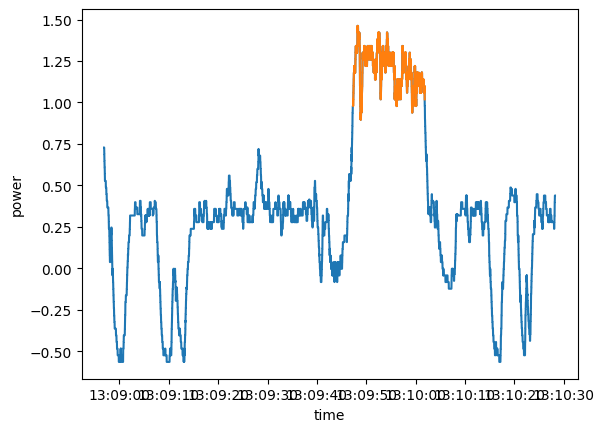

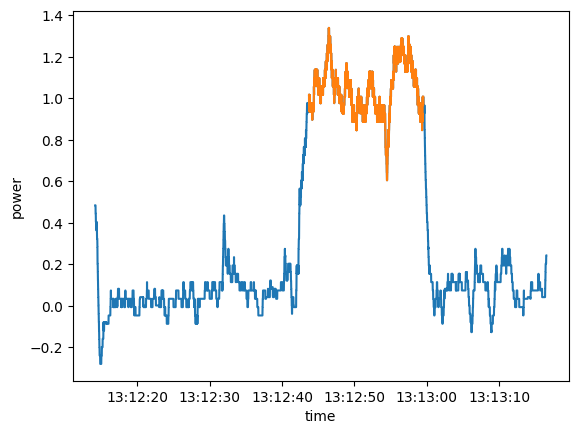

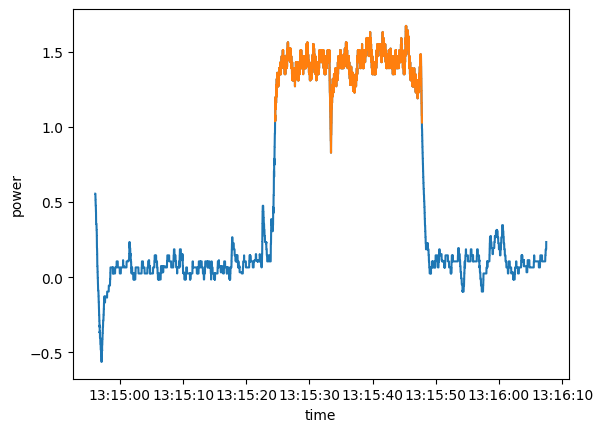

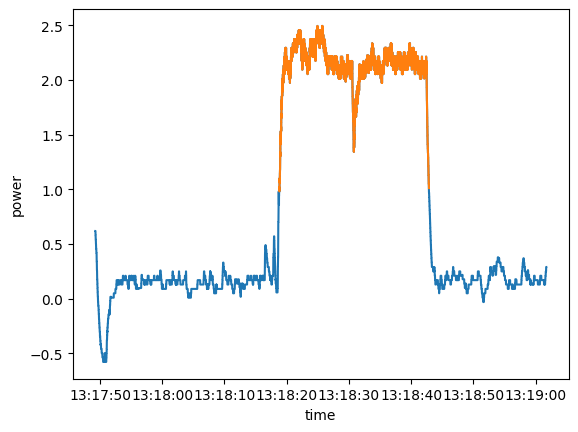

In [12]:
measurements_df = pd.DataFrame({model_name: calculate_metrics(model_name, plot=True) for model_name in model_variants}).T

In [13]:
measurements_df

,mean_active_power,max_active_power,wall_time,active_time,inference_time,mean_active_energy,max_active_energy,mean_inference_energy,max_inference_energy,integrated_energy,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),fitness
yolov5nu_trt.engine,1.202975,1.461284,91.374845,14.516418,11.273579,17.462885,21.212611,13.561832,16.473902,17.452951,0.052957,0.034601,0.035153,0.020638,0.022090
yolov5su_trt.engine,1.041901,1.337798,62.289795,15.780688,13.643351,16.441918,21.111369,14.215024,18.252045,16.452280,0.204584,0.296914,0.257314,0.163252,0.172658
yolov5mu_trt.engine,1.413741,1.670032,71.390340,23.258480,26.221472,32.881469,38.842415,37.070372,43.790707,32.898217,0.195653,0.615319,0.466195,0.288822,0.306560
yolov5lu_trt.engine,2.137916,2.495686,72.456372,24.070232,26.513905,51.460133,60.071738,56.684499,66.170377,51.483462,0.167297,0.651673,0.486067,0.302562,0.320913


Model Quantization Measurements

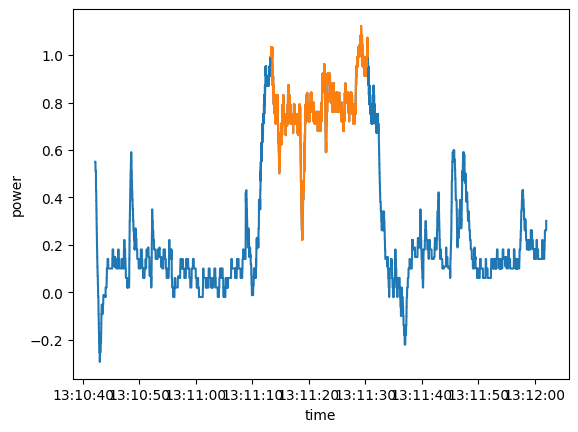

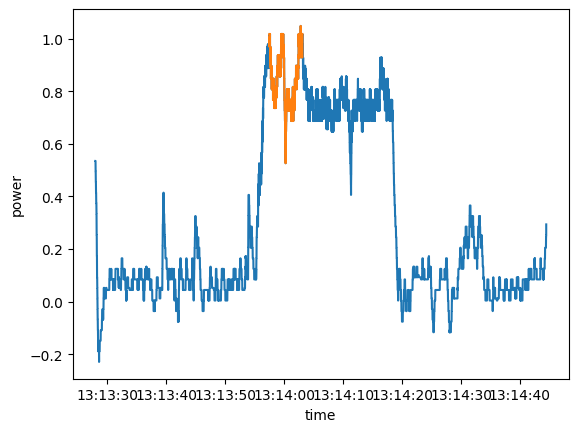

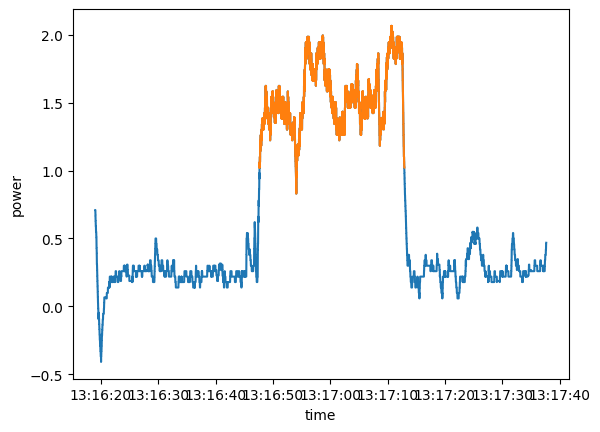

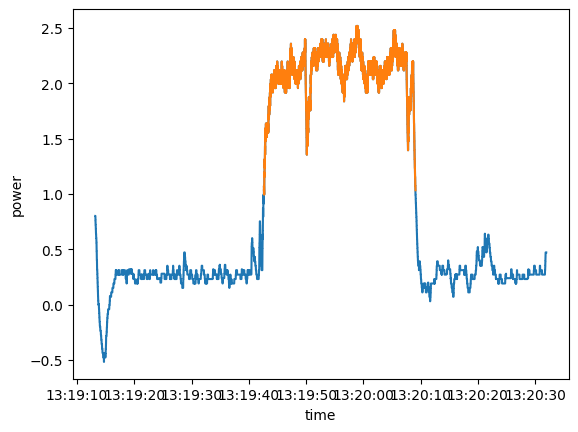

In [14]:
quant_measurements_df = pd.DataFrame({model_name: calculate_metrics(model_name, index=1000, plot=True) for model_name in quant_model_variants}).T

In [15]:
quant_measurements_df

,mean_active_power,max_active_power,wall_time,active_time,inference_time,mean_active_energy,max_active_energy,mean_inference_energy,max_inference_energy,integrated_energy,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),fitness
yolov5nu_quant_trt.engine,0.785734,1.122914,79.850024,17.092996,14.351874,13.430543,19.193958,11.276751,16.115914,13.439099,0.580308,0.455445,0.497448,0.346300,0.361415
yolov5su_quant_trt.engine,0.843531,1.047852,76.466261,5.576402,16.827224,4.703865,5.843241,14.194277,17.632432,4.710335,0.680345,0.533097,0.593544,0.437794,0.453369
yolov5mu_quant_trt.engine,1.545620,2.064710,78.642029,25.249732,25.528475,39.026482,52.133384,39.457313,52.708908,39.104212,0.704691,0.585891,0.653162,0.495978,0.511697
yolov5lu_quant_trt.engine,2.105912,2.517505,78.774837,26.479523,28.870491,55.763558,66.662344,60.798726,72.681618,55.823162,0.712396,0.641581,0.692875,0.536879,0.552478


In [16]:
def scatter_text(x, y, text_column, data, title, xlabel, ylabel):
    """Scatter plot with country codes on the x y coordinates
       Based on this answer: https://stackoverflow.com/a/54789170/2641825"""
    # Create the scatter plot
    p1 = sns.scatterplot(x=x, y=y, data=data, size = 8, legend=False)
    # Add text besides each point
    for line in range(0,data.shape[0]):
         p1.text(data[x][line]+0.01, data[y][line], 
                 data[text_column][line], horizontalalignment='left', 
                 size='medium', color='black', weight='semibold')
    # Set title and axis labels
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    return p1

<Axes: title={'center': 'YOLOv5 Baseline'}, xlabel='Valdation Energy Consumption (J)', ylabel='mAP50-95'>

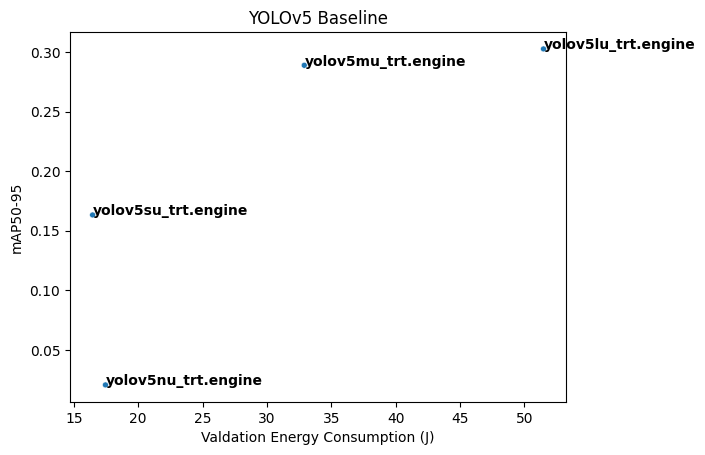

In [17]:
scatter_text("integrated_energy", "metrics/mAP50-95(B)", "index", data=measurements_df.reset_index(), title="YOLOv5 Baseline", xlabel="Valdation Energy Consumption (J)", ylabel="mAP50-95")

<Axes: title={'center': 'YOLOv5 Model Quantization (INT8 ONNX)'}, xlabel='Valdation Energy Consumption (J)', ylabel='mAP50-95'>

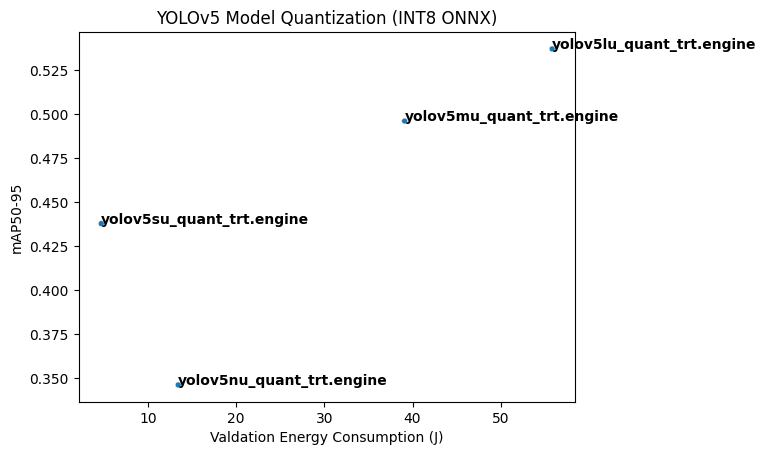

In [18]:
scatter_text("integrated_energy", "metrics/mAP50-95(B)", "index", data=quant_measurements_df.reset_index(), title="YOLOv5 Model Quantization (INT8 ONNX)", xlabel="Valdation Energy Consumption (J)", ylabel="mAP50-95")

<Axes: title={'center': 'YOLOv5 Baseline and Model Quantization'}, xlabel='Valdation Energy Consumption (J)', ylabel='mAP50-95'>

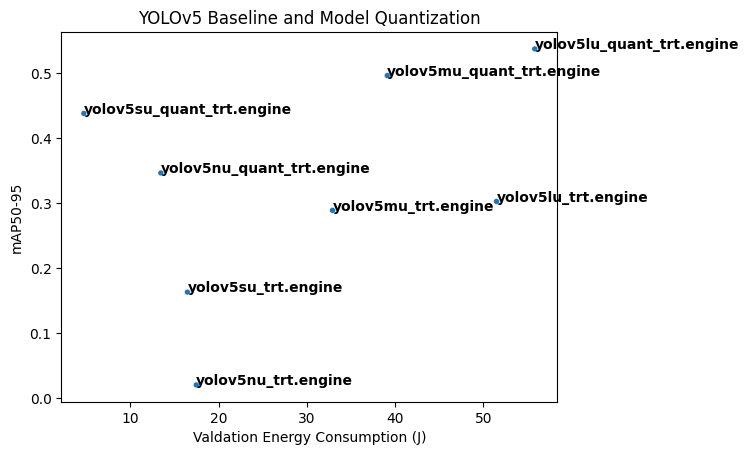

In [19]:
df = pd.concat([measurements_df.reset_index(), quant_measurements_df.reset_index()], ignore_index=True)
scatter_text("integrated_energy", "metrics/mAP50-95(B)", "index", data=df.reset_index(), title="YOLOv5 Baseline and Model Quantization", xlabel="Valdation Energy Consumption (J)", ylabel="mAP50-95")

In [20]:
df.to_csv("../processed_data/model_quantization_measurements_trt.csv")